In [ ]:
import os
from pathlib import Path
# Ensure CWD is repo root so relative paths and `tools.*` imports resolve.
if Path.cwd().name == "notebooks":
    os.chdir("..")


# NER com BiLSTM-CRF e Modelos BERT para o dataset decicontas.br

Este notebook implementa e avalia modelos de NER baseados em:
1. **BiLSTM-CRF** — arquitetura clássica de sequência com camada CRF
2. **BERTimbau** — BERT pré-treinado em português (neuralmind/bert-base-portuguese-cased)
3. **Legal-BERTimbau / albertina-ptbr** — variantes adaptadas ao domínio
4. **XLM-RoBERTa** — modelo multilíngue com forte generalização cross-lingual
5. **mDeBERTa** — DeBERTa multilíngue com atenção desacoplada (disentangled attention)

O dataset decicontas.br contém 178 decisões anotadas do TCE/RN com 4 tipos de entidade:
MULTA, OBRIGACAO, RECOMENDACAO, RESSARCIMENTO.

**Métricas**: Token-level (Precision, Recall, F1) e Span-level (F1 com IoU ≥ 0.5), compatíveis com o artigo decicontas.br.

**Tracking**: Resultados registrados no W&B project `eduardoplima-imd/decicontas.br`.

## 2. Carregamento e Preparação dos Dados

In [31]:
import wandb

wandb.login()
WANDB_PROJECT = 'decicontas.br'
WANDB_ENTITY = 'eduardoplima-imd'

import json
import gc
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from tools.dataset import get_decicontas_df

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


In [2]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: mps


In [3]:
import os
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

In [4]:
def load_decicontas():
    """Carrega o dataset decicontas via get_decicontas_df e converte para formato BIO."""
    df = get_decicontas_df()
    
    samples = []
    for _, row in df.iterrows():
        text = row['data']['text']
        annotations = row['annotations']
        
        # Extrair results de dentro da estrutura Label Studio
        results = []
        for ann in annotations:
            if isinstance(ann, dict) and 'result' in ann:
                results.extend(ann['result'])
            elif isinstance(ann, dict) and 'value' in ann:
                results.append(ann)
        
        spans = []
        for r in results:
            if 'value' in r and 'labels' in r['value']:
                val = r['value']
                spans.append({
                    'start': val['start'],
                    'end': val['end'],
                    'label': val['labels'][0]
                })
        
        samples.append({'text': text, 'spans': spans})
    
    
    annotated = [s for s in samples if s['spans']]
    print(f'Total de amostras: {len(samples)}, Anotadas: {len(annotated)}')
    return annotated

samples = load_decicontas()

Total de amostras: 866, Anotadas: 229


In [5]:
import re

def simple_tokenize(text):
    """Tokenização simples que preserva offsets de caractere."""
    tokens = []
    for m in re.finditer(r'\S+', text):
        tokens.append({
            'text': m.group(),
            'start': m.start(),
            'end': m.end()
        })
    return tokens

def spans_to_bio(tokens, spans):
    """Converte character-level spans para tags BIO em nível de token."""
    labels = ['O'] * len(tokens)
    
    for span in spans:
        s_start, s_end, s_label = span['start'], span['end'], span['label']
        first = True
        for i, tok in enumerate(tokens):
            # Token sobrepõe com o span
            if tok['start'] < s_end and tok['end'] > s_start:
                if first:
                    labels[i] = f'B-{s_label}'
                    first = False
                else:
                    labels[i] = f'I-{s_label}'
    
    return labels

# Converter tudo para formato BIO
bio_data = []
for s in samples:
    tokens = simple_tokenize(s['text'])
    labels = spans_to_bio(tokens, s['spans'])
    bio_data.append({
        'tokens': [t['text'] for t in tokens],
        'token_offsets': tokens,
        'labels': labels,
        'text': s['text'],
        'spans': s['spans']
    })

# Estatísticas
all_labels = [l for s in bio_data for l in s['labels']]
label_counts = Counter(all_labels)
print('Distribuição de tags BIO:')
for k, v in sorted(label_counts.items()):
    print(f'  {k}: {v}')

# Construir vocabulários
unique_labels = sorted(set(all_labels))
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label = {i: l for l, i in label2id.items()}
print(f'\nTotal de tags: {len(unique_labels)}')
print(unique_labels)

Distribuição de tags BIO:
  B-MULTA: 202
  B-OBRIGACAO: 119
  B-RECOMENDACAO: 56
  B-RESSARCIMENTO: 62
  I-MULTA: 11020
  I-OBRIGACAO: 7769
  I-RECOMENDACAO: 2075
  I-RESSARCIMENTO: 2865
  O: 29264

Total de tags: 9
['B-MULTA', 'B-OBRIGACAO', 'B-RECOMENDACAO', 'B-RESSARCIMENTO', 'I-MULTA', 'I-OBRIGACAO', 'I-RECOMENDACAO', 'I-RESSARCIMENTO', 'O']


In [6]:
# Split 80/10/10
train_data, temp_data = train_test_split(bio_data, test_size=0.2, random_state=SEED)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=SEED)

print(f'Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')

Train: 183, Val: 23, Test: 23


## 3. Funções de Avaliação

Métricas compatíveis com o artigo:
- **Token-level**: Precision, Recall, F1 (micro) sobre sequências BIO
- **Span-level**: F1 com IoU ≥ 0.5 para correspondência de spans
- **seqeval**: Avaliação padrão CoNLL para NER

In [7]:
from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1_score
from seqeval.metrics import precision_score as seq_precision_score
from seqeval.metrics import recall_score as seq_recall_score
from sklearn.metrics import classification_report, f1_score


def compute_token_metrics(true_labels_flat, pred_labels_flat):
    """Métricas token-level (exclui 'O')."""
    entity_labels = sorted(set(true_labels_flat + pred_labels_flat) - {'O'})
    report = classification_report(
        true_labels_flat, pred_labels_flat,
        labels=entity_labels, output_dict=True, zero_division=0
    )
    micro_f1 = f1_score(
        true_labels_flat, pred_labels_flat,
        labels=entity_labels, average='micro', zero_division=0
    )
    return report, micro_f1


def extract_spans_from_bio(labels):
    """Extrai spans (start_idx, end_idx, label) de uma sequência BIO."""
    spans = []
    current_label = None
    start = None
    for i, tag in enumerate(labels):
        if tag.startswith('B-'):
            if current_label is not None:
                spans.append((start, i, current_label))
            current_label = tag[2:]
            start = i
        elif tag.startswith('I-'):
            if current_label is None or tag[2:] != current_label:
                if current_label is not None:
                    spans.append((start, i, current_label))
                current_label = tag[2:]
                start = i
        else:
            if current_label is not None:
                spans.append((start, i, current_label))
                current_label = None
    if current_label is not None:
        spans.append((start, len(labels), current_label))
    return spans


def compute_span_f1(true_labels_list, pred_labels_list, iou_threshold=0.5):
    """Span-level F1 com IoU >= threshold."""
    tp, fp, fn = 0, 0, 0
    per_entity = {}
    
    for true_labels, pred_labels in zip(true_labels_list, pred_labels_list):
        true_spans = extract_spans_from_bio(true_labels)
        pred_spans = extract_spans_from_bio(pred_labels)
        
        matched_true = set()
        matched_pred = set()
        
        for pi, ps in enumerate(pred_spans):
            for ti, ts in enumerate(true_spans):
                if ps[2] == ts[2] and ti not in matched_true:
                    # Calcular IoU
                    inter_start = max(ps[0], ts[0])
                    inter_end = min(ps[1], ts[1])
                    intersection = max(0, inter_end - inter_start)
                    union = (ps[1] - ps[0]) + (ts[1] - ts[0]) - intersection
                    iou = intersection / union if union > 0 else 0
                    
                    if iou >= iou_threshold:
                        matched_true.add(ti)
                        matched_pred.add(pi)
                        label = ps[2]
                        per_entity.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})
                        per_entity[label]['tp'] += 1
                        break
        
        for pi, ps in enumerate(pred_spans):
            if pi not in matched_pred:
                fp += 1
                label = ps[2]
                per_entity.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})
                per_entity[label]['fp'] += 1
        
        for ti, ts in enumerate(true_spans):
            if ti not in matched_true:
                fn += 1
                label = ts[2]
                per_entity.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})
                per_entity[label]['fn'] += 1
        
        tp += len(matched_pred)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    per_entity_f1 = {}
    for label, counts in per_entity.items():
        p = counts['tp'] / (counts['tp'] + counts['fp']) if (counts['tp'] + counts['fp']) > 0 else 0
        r = counts['tp'] / (counts['tp'] + counts['fn']) if (counts['tp'] + counts['fn']) > 0 else 0
        per_entity_f1[label] = 2 * p * r / (p + r) if (p + r) > 0 else 0
    
    return {'precision': precision, 'recall': recall, 'f1': f1, 'per_entity_f1': per_entity_f1}


def full_evaluation(true_labels_list, pred_labels_list, model_name='Model'):
    """Avaliação completa: token-level + span-level + seqeval."""
    # Flatten para token-level
    true_flat = [l for seq in true_labels_list for l in seq]
    pred_flat = [l for seq in pred_labels_list for l in seq]
    
    _, token_f1 = compute_token_metrics(true_flat, pred_flat)
    span_results = compute_span_f1(true_labels_list, pred_labels_list)
    
    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    print(f'Token-level F1 (micro, excl. O): {token_f1:.4f}')
    print(f'Span-level F1 (IoU >= 0.5):      {span_results["f1"]:.4f}')
    print(f'Span-level Precision:             {span_results["precision"]:.4f}')
    print(f'Span-level Recall:                {span_results["recall"]:.4f}')
    print(f'\nPer-entity Span F1:')
    for ent, f1_val in sorted(span_results['per_entity_f1'].items()):
        print(f'  {ent}: {f1_val:.4f}')
    
    # seqeval report
    print(f'\nseqeval Classification Report:')
    print(seq_classification_report(true_labels_list, pred_labels_list, zero_division=0))
    
    return {
        'model': model_name,
        'token_f1': token_f1,
        'span_f1': span_results['f1'],
        'span_precision': span_results['precision'],
        'span_recall': span_results['recall'],
        'per_entity_f1': span_results['per_entity_f1']
    }

---
## 4. Modelo BiLSTM-CRF

Implementação de um BiLSTM-CRF com embeddings treináveis.  
Referência: Huang et al. (2015), Lample et al. (2016).

In [ ]:
from TorchCRF import CRF

In [9]:


# Construir vocabulário de palavras
word_freq = Counter()
for s in bio_data:
    for t in s['tokens']:
        word_freq[t.lower()] += 1

# Manter palavras com freq >= 1
vocab = ['<PAD>', '<UNK>'] + [w for w, c in word_freq.most_common() if c >= 1]
word2id = {w: i for i, w in enumerate(vocab)}
print(f'Vocab size: {len(vocab)}')


class NERDataset(Dataset):
    def __init__(self, data, word2id, label2id, max_len=512):
        self.data = data
        self.word2id = word2id
        self.label2id = label2id
        self.max_len = max_len
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        tokens = self.data[idx]['tokens'][:self.max_len]
        labels = self.data[idx]['labels'][:self.max_len]
        
        input_ids = [self.word2id.get(t.lower(), self.word2id['<UNK>']) for t in tokens]
        label_ids = [self.label2id[l] for l in labels]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'labels': torch.tensor(label_ids, dtype=torch.long),
            'length': len(input_ids)
        }


def collate_fn(batch):
    max_len = max(b['length'] for b in batch)
    
    input_ids = torch.zeros(len(batch), max_len, dtype=torch.long)
    labels = torch.zeros(len(batch), max_len, dtype=torch.long)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    
    for i, b in enumerate(batch):
        l = b['length']
        input_ids[i, :l] = b['input_ids']
        labels[i, :l] = b['labels']
        mask[i, :l] = True
    
    return {'input_ids': input_ids, 'labels': labels, 'mask': mask}


train_dataset = NERDataset(train_data, word2id, label2id)
val_dataset = NERDataset(val_data, word2id, label2id)
test_dataset = NERDataset(test_data, word2id, label2id)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

Vocab size: 4305


In [10]:
class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim // 2,
            num_layers=2, bidirectional=True, batch_first=True, dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_labels)
        self.crf = CRF(num_labels, batch_first=True)
    
    def forward(self, input_ids, labels=None, mask=None):
        embeds = self.dropout(self.embedding(input_ids))
        lstm_out, _ = self.lstm(embeds)
        emissions = self.fc(self.dropout(lstm_out))
        
        if labels is not None:
            loss = -self.crf(emissions, labels, mask=mask, reduction='mean')
            return loss
        else:
            return self.crf.decode(emissions, mask=mask)


EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LABELS = len(unique_labels)

bilstm_model = BiLSTM_CRF(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=NUM_LABELS
).to(device)

print(f'Parâmetros: {sum(p.numel() for p in bilstm_model.parameters()):,}')

Parâmetros: 1,212,908


In [11]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name='BiLSTM-CRF',
    config={'model': 'BiLSTM-CRF', 'lr': 1e-3, 'epochs': 50, 'seed': SEED}
)

optimizer = AdamW(bilstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 50
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 10

for epoch in range(EPOCHS):
    # Train
    bilstm_model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        loss = bilstm_model(
            batch['input_ids'].to(device),
            batch['labels'].to(device),
            batch['mask'].to(device)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bilstm_model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
    
    # Validate
    bilstm_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            loss = bilstm_model(
                batch['input_ids'].to(device),
                batch['labels'].to(device),
                batch['mask'].to(device)
            )
            val_loss += loss.item()
    
    avg_train = total_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    scheduler.step(avg_val)
    
    wandb.log({'train_loss': avg_train, 'val_loss': avg_val, 'epoch': epoch + 1})
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(bilstm_model.state_dict(), 'best_bilstm_crf.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')
    
    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

print('Treinamento BiLSTM-CRF concluído.')


Epoch 5/50 | Train Loss: 116.4775 | Val Loss: 158.8352
Epoch 10/50 | Train Loss: 55.5737 | Val Loss: 138.7704
Epoch 15/50 | Train Loss: 30.7512 | Val Loss: 142.7320
Early stopping at epoch 16
Treinamento BiLSTM-CRF concluído.


In [12]:
# Carregar melhor modelo e avaliar no test set
bilstm_model.load_state_dict(torch.load('best_bilstm_crf.pt', map_location=device))
bilstm_model.eval()

all_true_bilstm = []
all_pred_bilstm = []

with torch.no_grad():
    for i, sample in enumerate(test_data):
        tokens = sample['tokens'][:512]
        true_labels = sample['labels'][:512]
        
        input_ids = torch.tensor(
            [[word2id.get(t.lower(), word2id['<UNK>']) for t in tokens]],
            dtype=torch.long
        ).to(device)
        mask = torch.ones_like(input_ids, dtype=torch.bool).to(device)
        
        pred_ids = bilstm_model(input_ids, mask=mask)[0]
        pred_labels = [id2label[p] for p in pred_ids]
        
        all_true_bilstm.append(true_labels)
        all_pred_bilstm.append(pred_labels)

bilstm_results = full_evaluation(all_true_bilstm, all_pred_bilstm, 'BiLSTM-CRF')

wandb.init(project=WANDB_PROJECT, name="bilstm-crf-test", reinit=True)

wandb.log({
    'test/token_f1': bilstm_results['token_f1'],
    'test/span_f1': bilstm_results['span_f1'],
    'test/span_precision': bilstm_results['span_precision'],
    'test/span_recall': bilstm_results['span_recall'],
})
wandb.finish()



  BiLSTM-CRF
Token-level F1 (micro, excl. O): 0.6929
Span-level F1 (IoU >= 0.5):      0.4667
Span-level Precision:             0.4118
Span-level Recall:                0.5385

Per-entity Span F1:
  MULTA: 0.6207
  OBRIGACAO: 0.4571
  RECOMENDACAO: 0.4706
  RESSARCIMENTO: 0.0000

seqeval Classification Report:
               precision    recall  f1-score   support

        MULTA       0.31      0.38      0.34        13
    OBRIGACAO       0.00      0.00      0.00        18
 RECOMENDACAO       0.00      0.00      0.00         5
RESSARCIMENTO       0.00      0.00      0.00         3

    micro avg       0.10      0.13      0.11        39
    macro avg       0.08      0.10      0.09        39
 weighted avg       0.10      0.13      0.11        39



epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
train_loss,█▅▄▄▃▂▂▂▂▂▁▁▁▁▁▁
val_loss,█▄▂▁▃▁▁▂▄▂▁▁▂▁▂▂
epoch,16
train_loss,29.88975
val_loss,143.3098


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


test/span_f1,▁
test/span_precision,▁
test/span_recall,▁
test/token_f1,▁
test/span_f1,0.46667
test/span_precision,0.41176
test/span_recall,0.53846
test/token_f1,0.69292


In [32]:
CHECKPOINT_DIR = Path("dataset/results/checkpoints").resolve()
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


bilstm_ckpt = {
    "true_labels": all_true_bilstm,
    "pred_labels": all_pred_bilstm,
}
with open(CHECKPOINT_DIR / "bilstm-crf__test.pkl", "wb") as f:
    pickle.dump(bilstm_ckpt, f)

# Log no wandb com tabela de predições
wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="bilstm-crf__test",
           config={"model": "BiLSTM-CRF", "technique": "supervised"})

wandb.log({
    "token_f1": bilstm_results["token_f1"],
    "span_f1": bilstm_results["span_f1"],
    "span_precision": bilstm_results["span_precision"],
    "span_recall": bilstm_results["span_recall"],
    **{f"f1_{k}": v for k, v in bilstm_results["per_entity_f1"].items()},
})

# Tabela com predições por documento
table = wandb.Table(columns=["doc_idx", "true_bio", "pred_bio"])
for i, (t, p) in enumerate(zip(all_true_bilstm, all_pred_bilstm)):
    table.add_data(i, " ".join(t), " ".join(p))
wandb.log({"predictions": table})

wandb.finish()

f1_MULTA,▁
f1_OBRIGACAO,▁
f1_RECOMENDACAO,▁
f1_RESSARCIMENTO,▁
span_f1,▁
span_precision,▁
span_recall,▁
token_f1,▁
f1_MULTA,0.62069
f1_OBRIGACAO,0.45714
f1_RECOMENDACAO,0.47059


---
## 5. Modelos BERT para NER (Token Classification)

Fine-tuning de modelos BERT pré-treinados em português para classificação de tokens.

Modelos avaliados:
1. **BERTimbau** (`neuralmind/bert-base-portuguese-cased`) — BERT base para PT-BR
2. **BERTimbau Large** (`neuralmind/bert-large-portuguese-cased`) — versão large
3. **XLM-RoBERTa** (`xlm-roberta-base`) — multilingual, forte em NER cross-lingual

Todos usam `AutoModelForTokenClassification` do HuggingFace.

In [13]:
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
    EarlyStoppingCallback
)


class NERTokenDataset(Dataset):
    """Dataset que alinha BIO labels com sub-tokens do tokenizer BERT."""
    
    def __init__(self, data, tokenizer, label2id, max_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        tokens = sample['tokens']
        labels = sample['labels']
        
        # Tokenizar com is_split_into_words=True para alinhar sub-tokens
        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=self.max_length,
            truncation=True,
            padding=False,
            return_offsets_mapping=False
        )
        
        # Alinhar labels com word_ids
        word_ids = encoding.word_ids()
        aligned_labels = []
        previous_word_id = None
        
        for word_id in word_ids:
            if word_id is None:
                aligned_labels.append(-100)  # tokens especiais
            elif word_id != previous_word_id:
                aligned_labels.append(self.label2id[labels[word_id]])
            else:
                # Sub-tokens: copiar label do primeiro sub-token
                lbl = labels[word_id]
                if lbl.startswith('B-'):
                    aligned_labels.append(self.label2id['I-' + lbl[2:]])
                else:
                    aligned_labels.append(self.label2id[lbl])
            previous_word_id = word_id
        
        encoding['labels'] = aligned_labels
        return {k: torch.tensor(v) for k, v in encoding.items()}


def compute_metrics_hf(eval_pred):
    """Callback de métricas para o Trainer."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)
    
    true_labels_list = []
    pred_labels_list = []
    
    for pred_seq, label_seq in zip(predictions, labels):
        true_seq = []
        pred_seq_clean = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                true_seq.append(id2label[l])
                pred_seq_clean.append(id2label[p])
        true_labels_list.append(true_seq)
        pred_labels_list.append(pred_seq_clean)
    
    return {
        'f1': seq_f1_score(true_labels_list, pred_labels_list, zero_division=0),
        'precision': seq_precision_score(true_labels_list, pred_labels_list, zero_division=0),
        'recall': seq_recall_score(true_labels_list, pred_labels_list, zero_division=0),
    }

In [33]:
def train_and_evaluate_bert(model_name, train_data, val_data, test_data,
                            label2id, id2label, epochs=15, batch_size=8, lr=3e-5):
    """
    Fine-tune e avalia um modelo BERT para NER (otimizado para memória).
    Retorna métricas e predições no test set.
    """
    print(f'\n{"#"*60}')
    print(f'  Treinando: {model_name}')
    print(f'{"#"*60}')
    
    wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=model_name.split('/')[-1],
        config={'model': model_name, 'lr': lr, 'epochs': epochs, 'batch_size': batch_size, 'seed': SEED}
    )
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )
    
    train_ds = NERTokenDataset(train_data, tokenizer, label2id)
    val_ds = NERTokenDataset(val_data, tokenizer, label2id)
    test_ds = NERTokenDataset(test_data, tokenizer, label2id)
    
    data_collator = DataCollatorForTokenClassification(tokenizer, padding=True)
    
    output_dir = f'./results_{model_name.replace("/", "_")}'
    
    # Modo seguro para modelos com vocabulário grande (ex: xlm-roberta)
    is_large_vocab = 'xlm' in model_name.lower() or 'roberta' in model_name.lower()
    
    if is_large_vocab:
        effective_batch_size = 1
        accum_steps = 8
    else:
        effective_batch_size = batch_size
        accum_steps = max(1, 8 // batch_size)
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy='epoch',
        save_strategy='epoch',
        learning_rate=lr,
        per_device_train_batch_size=effective_batch_size,
        per_device_eval_batch_size=effective_batch_size,
        gradient_accumulation_steps=accum_steps,
        num_train_epochs=epochs,
        weight_decay=0.01,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        save_total_limit=1,
        logging_steps=10,
        fp16=torch.cuda.is_available(),
        gradient_checkpointing=True,
        optim='adafactor',
        max_grad_norm=1.0,
        dataloader_pin_memory=False,
        dataloader_num_workers=0,
        eval_accumulation_steps=4,
        report_to='wandb',
        seed=SEED,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics_hf,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )
    
    trainer.train()
    
    # Predição no test set
    predictions = trainer.predict(test_ds)
    preds = np.argmax(predictions.predictions, axis=2)
    labels_arr = predictions.label_ids
    
    true_labels_list = []
    pred_labels_list = []
    
    for pred_seq, label_seq in zip(preds, labels_arr):
        true_seq = []
        pred_seq_clean = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                true_seq.append(id2label[l])
                pred_seq_clean.append(id2label[p])
        true_labels_list.append(true_seq)
        pred_labels_list.append(pred_seq_clean)
    
    results = full_evaluation(true_labels_list, pred_labels_list, model_name)

    # Salvar predições
    ckpt = {
    "true_labels": true_labels_list,
    "pred_labels": pred_labels_list,
    "results": results,
    }
    safe_name = model_name.replace("/", "_").replace(".", "-")
    with open(CHECKPOINT_DIR / f"{safe_name}__supervised.pkl", "wb") as f:
        pickle.dump(ckpt, f)
    
    table = wandb.Table(columns=["doc_idx", "true_bio", "pred_bio"])
    for i, (t, p) in enumerate(zip(true_labels_list, pred_labels_list)):
        table.add_data(i, " ".join(t), " ".join(p))
    wandb.log({"predictions": table})
    wandb.log({
        'test/token_f1': results['token_f1'],
        # ... resto das métricas
        **{f"test/f1_{k}": v for k, v in results["per_entity_f1"].items()},
    })
    wandb.finish()

    # Cleanup
    del model, trainer, train_ds, val_ds, test_ds, predictions, preds, labels_arr
    gc.collect()
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    return results

In [34]:
# Lista de modelos BERT a avaliar
BERT_MODELS = [
    'neuralmind/bert-base-portuguese-cased',     # BERTimbau base
    'neuralmind/bert-large-portuguese-cased',     # BERTimbau large
    #'xlm-roberta-base',                           # XLM-RoBERTa
    'microsoft/mdeberta-v3-base',                 # mDeBERTa v3
]

# Modelos adaptados ao domínio jurídico PT-BR
BERT_MODELS += [
     'rufimelo/Legal-BERTimbau-base',            # BERT jurídico PT
     'PORTULAN/albertina-ptbr',                   # Albertina PT-BR
]


In [ ]:
all_results = [bilstm_results]  # já temos o BiLSTM-CRF

for model_name in BERT_MODELS:
    try:
        results = train_and_evaluate_bert(
            model_name=model_name,
            train_data=train_data,
            val_data=val_data,
            test_data=test_data,
            label2id=label2id,
            id2label=id2label,
            epochs=15,
            batch_size=2,    # reduzido de 8 para evitar OOM
            lr=3e-5
        )
        all_results.append(results)
    except Exception as e:
        print(f'ERRO com {model_name}: {e}')


############################################################
  Treinando: neuralmind/bert-base-portuguese-cased
############################################################


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 46692.92it/s]
BertForTokenClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,6.863513,0.956007,0.000000,0.000000,0.000000
2,2.193420,0.414970,0.092857,0.053719,0.342105
3,1.022335,0.276924,0.155689,0.100775,0.342105
4,0.825484,0.208901,0.183007,0.121739,0.368421
5,0.383766,0.227308,0.389381,0.293333,0.578947
6,0.234311,0.229595,0.478632,0.354430,0.736842
7,0.125046,0.234427,0.372093,0.263736,0.631579
8,0.179594,0.249749,0.589474,0.491228,0.736842
9,0.061189,0.286669,0.563107,0.446154,0.763158
10,0.063271,0.282289,0.600000,0.483871,0.789474


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.00it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


  neuralmind/bert-base-portuguese-cased
Token-level F1 (micro, excl. O): 0.8778
Span-level F1 (IoU >= 0.5):      0.3976
Span-level Precision:             0.2598
Span-level Recall:                0.8462

Per-entity Span F1:
  MULTA: 0.4898
  OBRIGACAO: 0.2921
  RECOMENDACAO: 0.6667
  RESSARCIMENTO: 0.4615

seqeval Classification Report:
               precision    recall  f1-score   support

        MULTA       0.22      0.62      0.33        13
    OBRIGACAO       0.07      0.28      0.11        18
 RECOMENDACAO       0.30      0.60      0.40         5
RESSARCIMENTO       0.20      0.67      0.31         3

    micro avg       0.14      0.46      0.22        39
    macro avg       0.20      0.54      0.29        39
 weighted avg       0.16      0.46      0.24        39



...

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,6.437500,1.028023,0.000000,0.000000,0.000000
2,2.913477,0.281144,0.089965,0.051587,0.351351
3,0.647369,0.477741,0.209302,0.133333,0.486486
4,0.707054,0.180006,0.236686,0.151515,0.540541
5,0.309592,0.368069,0.465116,0.326087,0.810811
6,0.102005,0.097774,0.696629,0.596154,0.837838
7,0.082177,0.104839,0.632653,0.508197,0.837838
8,0.151816,0.109154,0.557692,0.432836,0.783784
9,0.033245,0.089250,0.752941,0.666667,0.864865
10,0.017000,0.097589,0.735632,0.640000,0.864865


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.45s/it]
There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.la


  PORTULAN/albertina-ptbr
Token-level F1 (micro, excl. O): 0.9400
Span-level F1 (IoU >= 0.5):      0.6667
Span-level Precision:             0.5303
Span-level Recall:                0.8974

Per-entity Span F1:
  MULTA: 0.7742
  OBRIGACAO: 0.5660
  RECOMENDACAO: 0.6667
  RESSARCIMENTO: 1.0000

seqeval Classification Report:
               precision    recall  f1-score   support

        MULTA       0.44      0.62      0.52        13
    OBRIGACAO       0.37      0.72      0.49        18
 RECOMENDACAO       0.30      0.60      0.40         5
RESSARCIMENTO       0.67      0.67      0.67         3

    micro avg       0.39      0.67      0.50        39
    macro avg       0.45      0.65      0.52        39
 weighted avg       0.41      0.67      0.50        39



eval/f1,▁▂▃▃▅▇▇▆█▇█████
eval/loss,█▂▄▂▃▁▁▁▁▁▁▁▁▁▁
eval/precision,▁▂▂▂▄▇▆▅█▇█████
eval/recall,▁▄▅▅▇██▇███████
eval/runtime,▂▁▁▂▁█▆▆▁▂▂▃▁▁▂
eval/samples_per_second,▇██▇█▁▃▃█▇▆▆██▇
eval/steps_per_second,▇██▇█▁▃▃█▇▆▆██▇
test/f1,▁
test/f1_MULTA,▁
test/f1_OBRIGACAO,▁
+14,...


: 

In [25]:
all_results

[{'model': 'BiLSTM-CRF',
  'token_f1': 0.6929175475687104,
  'span_f1': 0.4666666666666667,
  'span_precision': 0.4117647058823529,
  'span_recall': 0.5384615384615384,
  'per_entity_f1': {'MULTA': 0.6206896551724138,
   'OBRIGACAO': 0.45714285714285713,
   'RESSARCIMENTO': 0,
   'RECOMENDACAO': 0.47058823529411764}},
 {'model': 'neuralmind/bert-base-portuguese-cased',
  'token_f1': 0.8977621763931549,
  'span_f1': 0.47826086956521735,
  'span_precision': 0.3333333333333333,
  'span_recall': 0.8461538461538461,
  'per_entity_f1': {'MULTA': 0.4313725490196079,
   'OBRIGACAO': 0.44776119402985076,
   'RECOMENDACAO': 0.9090909090909091,
   'RESSARCIMENTO': 0.4444444444444444}},
 {'model': 'neuralmind/bert-large-portuguese-cased',
  'token_f1': 0.8977955911823647,
  'span_f1': 0.4848484848484849,
  'span_precision': 0.34408602150537637,
  'span_recall': 0.8205128205128205,
  'per_entity_f1': {'MULTA': 0.5641025641025641,
   'OBRIGACAO': 0.3823529411764706,
   'RESSARCIMENTO': 0.5,
   'RECO

---
## 6. Comparação Final de Resultados

In [17]:
# Tabela comparativa
comparison_rows = []
for r in all_results:
    row = {
        'Model': r['model'],
        'Token F1': f"{r['token_f1']:.4f}",
        'Span F1': f"{r['span_f1']:.4f}",
        'Span P': f"{r['span_precision']:.4f}",
        'Span R': f"{r['span_recall']:.4f}",
    }
    for ent, f1_val in sorted(r.get('per_entity_f1', {}).items()):
        row[f'F1-{ent}'] = f"{f1_val:.4f}"
    comparison_rows.append(row)

df_results = pd.DataFrame(comparison_rows)
print('\n' + '='*80)
print('COMPARAÇÃO FINAL — TODOS OS MODELOS')
print('='*80)
print(df_results.to_string(index=False))

# Incluir resultados LLM do artigo original para referência
print('\n\nReferência do artigo (LLMs com few-shot prompting):')
print('  gpt-4-turbo:  Token F1=0.7945 | Span F1=0.7524')
print('  gpt-4o:       Token F1=0.7813 | Span F1=0.7381')
print('  gpt-41-mini:  Token F1=0.7784 | Span F1=0.7399')


COMPARAÇÃO FINAL — TODOS OS MODELOS
                                 Model Token F1 Span F1 Span P Span R F1-MULTA F1-OBRIGACAO F1-RECOMENDACAO F1-RESSARCIMENTO
                            BiLSTM-CRF   0.6929  0.4667 0.4118 0.5385   0.6207       0.4571          0.4706           0.0000
 neuralmind/bert-base-portuguese-cased   0.8978  0.4783 0.3333 0.8462   0.4314       0.4478          0.9091           0.4444
neuralmind/bert-large-portuguese-cased   0.8978  0.4848 0.3441 0.8205   0.5641       0.3824          0.7692           0.5000
         rufimelo/Legal-BERTimbau-base   0.8574  0.5156 0.3708 0.8462   0.5789       0.4179          0.8333           0.5455
               PORTULAN/albertina-ptbr   0.9461  0.7391 0.6415 0.8718   0.7059       0.7317          0.7273           1.0000


Referência do artigo (LLMs com few-shot prompting):
  gpt-4-turbo:  Token F1=0.7945 | Span F1=0.7524
  gpt-4o:       Token F1=0.7813 | Span F1=0.7381
  gpt-41-mini:  Token F1=0.7784 | Span F1=0.7399


In [24]:
df_results.to_excel('dataset/results/results_bert.xlsx', index=False)

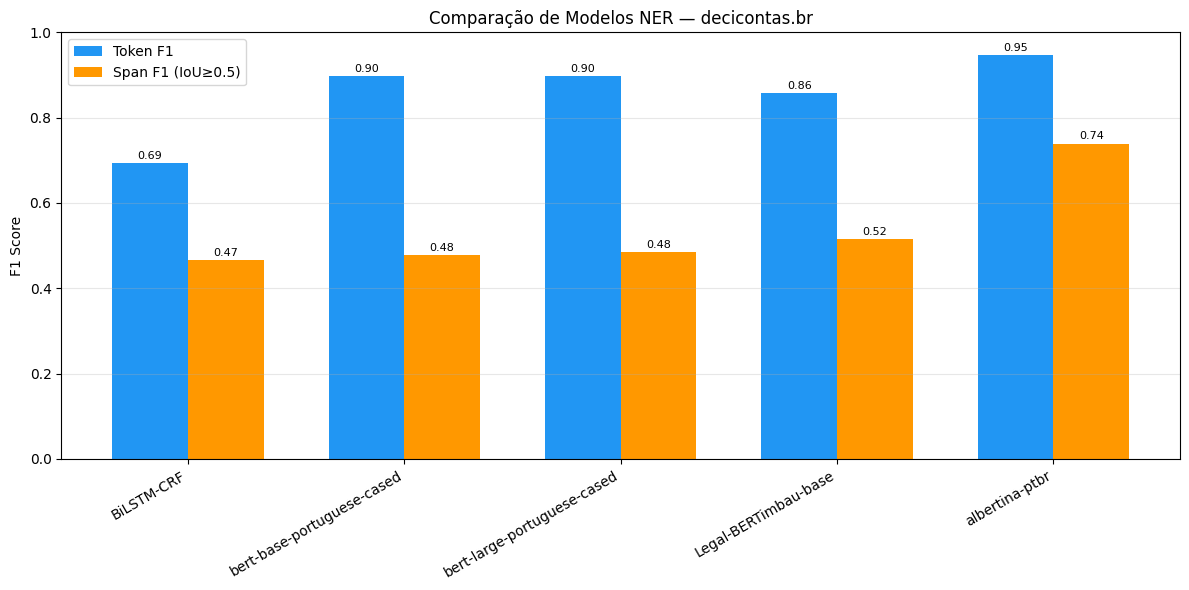

In [18]:
import matplotlib.pyplot as plt

models = [r['model'] for r in all_results]
token_f1s = [r['token_f1'] for r in all_results]
span_f1s = [r['span_f1'] for r in all_results]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, token_f1s, width, label='Token F1', color='#2196F3')
bars2 = ax.bar(x + width/2, span_f1s, width, label='Span F1 (IoU≥0.5)', color='#FF9800')

ax.set_ylabel('F1 Score')
ax.set_title('Comparação de Modelos NER — decicontas.br')
ax.set_xticks(x)
ax.set_xticklabels([m.split('/')[-1] for m in models], rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('ner_comparison.png', dpi=150)
plt.show()

In [19]:
# Salvar resultados em JSON
import json

with open('ner_results_all_models.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

print('Resultados salvos em ner_results_all_models.json')

Resultados salvos em ner_results_all_models.json
